# C.1: Visualising Event Data

We will use [pandas](https://pandas.pydata.org), a ubiquitous python _DataFrame_ analysis library, to investigate the results of a _partial_ experimental simulation and, later, write the final missing step in the simulation using pandas. Because pandas is such a central tool in data science (while actually being less commonly used in HEP), you should be able to use a search engine to find additional help with any issues encountered. But, please do also ask if you get too stuck!

We have provided two data files, one contains simulated neutrino interactions ([Events](./6Glossary.ipynb#event)) occuring in a muon neutrino beam and one contains events simulated in a muon antineutrino beam. Both correspond to interactions taking place in DUNE's _far detector_ and so even though the simulated neutrino beam initially only contained muon (anti)neutrinos, the events here are simulated with both muon and electron flavor neutrinos to allow you to fully simulate and study an oscillation experiment.

In [1]:
import pandas as pa

simulated_events_nu_mode = pa.read_csv("simulation/neutrino_mode_events.csv")
simulated_events_antinu_mode = pa.read_csv("simulation/antineutrino_mode_events.csv")

# If the object is left on the last line of the cell, Jupyter will show the dataframe
simulated_events_nu_mode

,event_num,pid_neutrino,E_neutrino,is_CC,pid_lepton,E_lepton,T_proton,num_pi0,E_pi0,num_cpi,T_cpi,E_nu_rec_true
0,79046,14,2.5481,1,13,2.0898,0.0796,0,0.0000,0,0.0000,2.1694
1,119433,12,9.6358,1,11,2.8707,0.1337,1,0.2670,0,0.0000,3.2715
2,15484,14,2.0445,1,13,1.7392,0.0937,0,0.0000,0,0.0000,1.8329
3,84504,14,4.2037,0,14,0.0000,0.2889,0,0.0000,0,0.0000,0.2889
4,141753,12,1.2580,1,11,0.2269,0.2973,0,0.0000,1,0.0359,0.6996
...,...,...,...,...,...,...,...,...,...,...,...,...
199995,191131,12,3.9009,1,11,2.1646,0.7903,1,0.7283,0,0.0000,3.6831
199996,134609,12,2.9689,1,11,2.1940,0.4876,0,0.0000,0,0.0000,2.6816
199997,192913,12,3.7822,1,11,0.2866,0.1183,1,3.3843,0,0.0000,3.7893
199998,62886,14,2.7919,1,13,1.0455,1.1384,1,0.2045,2,0.0960,2.7634


Look at the event data table above: Each row corresponds to a single simulated neutrino interaction (an _event_), and each column corresponds to a property of that event. A description of each event property follows:
* `event_num`: An index corresponding to the order of simulation, as events are entirely independent this property is irrelevant for our simulation.
* `pid_neutrino`: The [Particle IDentifier](./6Glossary.ipynb#pid) for the incoming neutrino. This tells us the neutrino [Flavor](./6Glossary.ipynb#flavor): electron or muon (or tau, but we wont see any tau neutrinos in this project).
* `E_neutrino`: The [Total Energy](./6Glossary.ipynb#energy) of the incoming neutrino.
* `is_CC`: Whether the interaction was [Charged Current](./6Glossary.ipynb#cc) or Neutral Current.
* `pid_lepton`: The [Particle IDentifier](./6Glossary.ipynb#pid) for the lepton that leaves the interaction.
* `E_lepton`: The [Total Energy](./6Glossary.ipynb#energy) for the lepton that leaves the interaction.
* `T_proton`: The sum of the [Kinetic Energies](./6Glossary.ipynb#energy) of all protons that leave the interaction.
* `num_pi0`: The number of [Neutral Pions]() that leave the interaction.
* `E_pi0`: The sum of the [Total Energies](./6Glossary.ipynb#energy) of all neutral pions that leave the interaction.
* `num_cpi`: The number of [Charged Pions]() that leave the interaction.
* `T_cpi`: The sum of the [Kinetic Energies](./6Glossary.ipynb#energy) of all [Charged Pions]() that leave the interaction.

All of the information in this table should be considered simulation [Truth](./6Glossary.ipynb#truth). Even the properties that might appear to be _observable_, like the total energy of neutral pions that are clearly visible in our detectors, in reality, detectors are never _perfect_ and always include some measurement error, or _detector smearing_, which is not included in this simulation. A bit later we will develop our own simple model of detector smearing and thus provide the final stage of the experiment simulation.

## C.1.1: What to do with all this data?
Particle physicists try to learn about the physical laws that govern the interactions of fundamental particles, in our case, neutrinos. The details of each interaction is, as far as we currently understand, random, but as we study many similar interactions we see patterns appear in the data. The way we learn about the physical laws is to try and build mathematical models that can accurately predict these patterns.

We will use [Histograms](./6Glossary.ipynb#histograms) to analyse samples of interactions to try and build up an understanding of important patterns in the simulation, and then use this understanding to analyse 'data', where we cannot _cheat_ by looking at the [Truth](./6Glossary.ipynb#truth) information. The results of our data analysis will be a measurement of a fundamental property of neutrinos and just might be able to tell us some new fundamental truth about nature and how the universe came to exist.

## C.1.2: My First Histogram

We can make histograms directly from pandas, like below:

<Axes: ylabel='Frequency'>

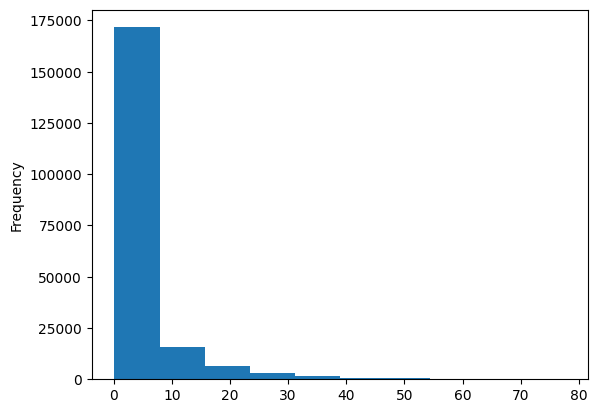

In [2]:
simulated_events_nu_mode["E_neutrino"].plot(kind='hist')

This is correct, the data has been sorted such that the number of rows with `E_nu` in a given _bin_ can be read off the above plot. However, it seems that almost all of our data falls in the first bin that spans $0 < E_\nu < 8$ GeV. Under the hood, pandas is using matplotlib and numpy to produce this plot, we will see very soon that our lives will be made easier by having more control and using those tools directly, but for now, lets play with the size and extent of the bins and see if we can find a scheme that might give us more useful information. We can change the binning scheme, as below, where we are using the numpy function `linspace` to generate a number of bin edges that are linearly spaced between two end points, as you can see in the following print out:

[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29. 30. 31. 32. 33. 34. 35.
 36. 37. 38. 39. 40. 41. 42. 43. 44. 45. 46. 47. 48. 49. 50. 51. 52. 53.
 54. 55.]


<Axes: ylabel='Frequency'>

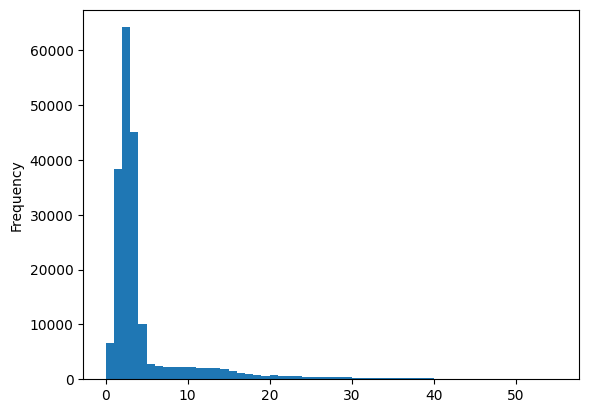

In [3]:
import numpy as np

# if you want bins of 1 GeV wide you will need 1 more edge than the range
#   as this function generates the bin edges, not the bins themselves. It
#   is equivalent to placing fence posts and the fence between them, you 
#   always need one more post than fence section because each end needs 
#   a post.
bins = np.linspace(start=0, stop=55, num=56)
print(bins)
simulated_events_nu_mode["E_neutrino"].plot(kind='hist', bins=bins)

This is better, but there is still a lot of information in few bins at 0-5 GeV. 

As we are attempting to study oscillations, can you remember (or go back and check) over what range the main oscillation affects occur for DUNE? Can you use that to guide your choice of binning energy range?

How do you know if you have too few bins? what about too many bins?

In [4]:
start = 0
stop = 8 # enter maximum binned energy here
nbins = 100 # enter a number of bins here
num = nbins + 1

<Axes: ylabel='Frequency'>

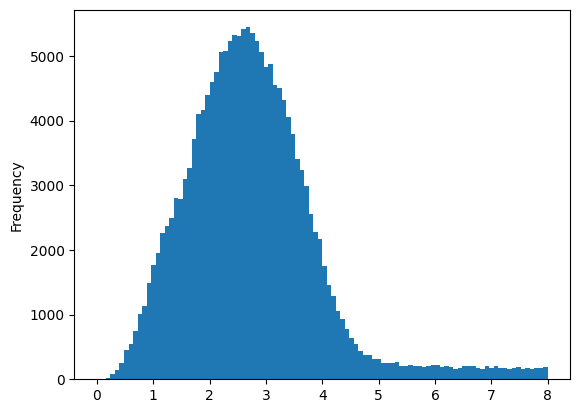

In [5]:
simulated_events_nu_mode["E_neutrino"].plot(kind='hist', bins=np.linspace(start=start, stop=stop, num=num))

We're nearly there with our first histogram, the final thing to do is to make sure it is fully annotated and looking attractive. Plot style is a very subjective thing and there are many many tutorials and opinions on the matter. I will give an example of some minimal changes that will make this figure a bit closer to publication quality, but you are welcome to spend time prettifying it further if you would like to.

**A Note on LaTeX**: In the cell below we set the x axis label to a string containing some, possibly surprising, characters. If you haven't seen $\LaTeX$ code before then it might be difficult to parse what each part does. [$\LaTeX$](https://www.latex-project.org) is a general typesetting tool that is used ubiquitously in science for publications, rendering mathematical formulae, and even creating diagrams. We can use a small subset of the $\LaTeX$ language to describe mathematical symbols that can be useful for figure annotations such as axis labels. For this project it is not worth your time trying to understand or learn LaTeX, but we will still use it in our examples and you should feel free to ask for help if you'd like to render a specific formulae.

The $\LaTeX$ code used in the example below: `$E_{\nu}$` will be rendered like $E_{\nu}$.


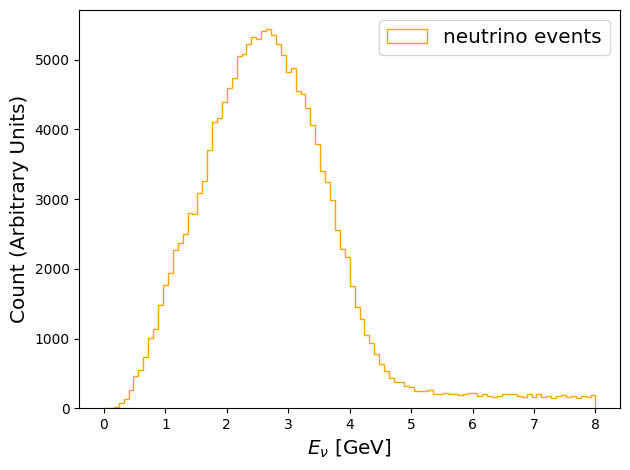

In [6]:
import matplotlib.pyplot as plt

simulated_events_nu_mode["E_neutrino"].plot(kind='hist', bins=np.linspace(start=start, stop=stop, num=num), histtype="step", color="orange", label="neutrino events")

plt.xlabel(r"$E_{\nu}$ [GeV]", size="x-large")
plt.ylabel("Count (Arbitrary Units)", size="x-large")

plt.legend(fontsize="x-large")
plt.tight_layout()
plt.show()

## C.1.3: My Second Histogram and Some Helpful Tools

We will use a number of other ubiquitous python libraries in this analysis, mostly: [numpy](), [matplotlib](), and [scipy](). You don't need to know anything about these tools already, but, like with pandas, you should be able to find help for any problems encountered via search engine results. In addition, we provide a few helpful tools so that you can get to analysis quickly, the code for these tools can be found in the [proj_utils](./proj_utils/__init__.py) module, but the hope is that you shouldn't need to see the details once you know how to use them.

Later we will need to access the histogram data, so it is useful now to get used to separating the histogram creation (or binning of the data) from the visualisation (or plotting) of the histogram. We introduce two helper function that you can use below, behind the scenes they are doing exactly the same thing using the same libraries as we did directly from pandas, but here we get a bit more control over the process. We will use this control more later.

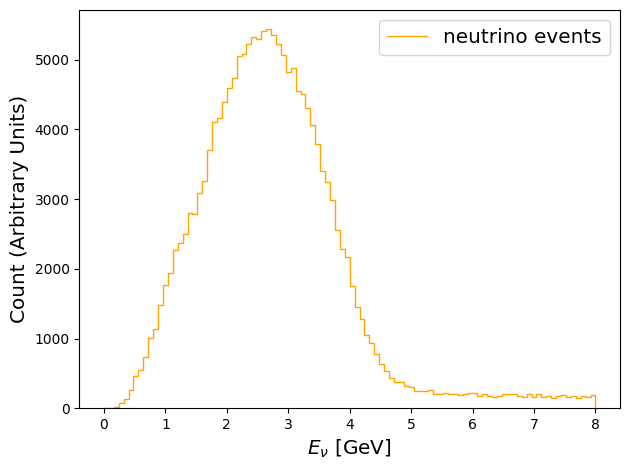

In [7]:
from proj_utils import hist1d, drawhist1d

enu_hist = hist1d(data=simulated_events_nu_mode["E_neutrino"], bins=np.linspace(start=start, stop=stop, num=num))
drawhist1d(hist=enu_hist, color="orange", label="neutrino events")

plt.xlabel(r"$E_{\nu}$ [GeV]", size="x-large")
plt.ylabel("Count (Arbitrary Units)", size="x-large")

plt.legend(fontsize="x-large")
plt.tight_layout()
plt.show()

Can you now draw the distribution of outgoing lepton energies by adapting the above code to plot a different event property?

In [8]:
# lep_hist = 
# ...

# C.2: Observable Distributions

So far we have looked at the neutrino energy, and the lepton energy that a perfect detector might see, both [true](./Glossary.ipynb#truth) quantities. We cannot observe true quantities in our real detectors and so we cannot compare our simulated predictions to real data in terms of true quantities. This doesn't mean that distributions of [true](./Glossary.ipynb#truth) quantities are not an important part of particle physics data analysis, they are, but we also need to be able to predict what a given event might look like in our real detectors. 

In a full experiment simulation, we would model and simulate every part of the detector and run the same event [reconstruction](./Glossary.ipynb#reconstruction) algorithms on the actual signals produced by our real detector and on the predicted signals from our simulated detector. We don't have the time or processing power to fully simulate the DUNE detectors and run the reconstruction algorithms, but that is okay, because the results of those algorithms often approximately follow relatively simple distributions. This is on purpose, we want the event reconstruction to tell us as much as possible as accurately as possible about what occured in the event in our detector.

## C.2.1: My First Monte Carlo Simulation

We will approximate the result of the reconstruction algorithms on individual particles produced in the neutrino interaction by using a [Gaussian](./Glossary.ipynb#gaussian) smearing. The Gaussian distribution, also known as the normal distribution, or sometimes _the bell curve_ appears everywhere in statistics and the simulation and characterisation of random processes. The mathematical form is relatively simple $$g(x) = \frac{1}{\sigma\sqrt{2\pi}}e^{\left[-(x-\mu)^2/2\sigma^2\right]},$$ where $\mu$ controls the center of the distribution (sometimes called the location), and $\sigma$ controls the width (sometimes called the scale). If you haven't seen $e^x$ before, then you can think of it as a generalisation of a formula like: $2.72^{3/2} = \sqrt{2.72 * 2.72 * 2.72}$. Euler's constant, $e$, is just a number, $e=2.7182...$, but with a some special properties, in a similar way to $\pi$ just being a number but with special properties. In terms of how to calculate a number to the power of another arbitrary number, we use the function `np.exp` to do the calculation for us and so don't need to worry about the details.

You can think of Gaussian smearing as like looking at an out of focus photograph, the more out of focus, the more blurred, and the _wider_ the gaussian smear. An object in the out-of-focus photo has some _true_ location relative to other objects in the photo, but it's apparent extent in the photo has been made larger and overlaps with other nearby objects. For us, a muon produced in a neutrino interaction has some _true_ energy, but our measurement of it is imperfect and we _observe_ energy that differs from the true energy. For a single event, the observed muon energy is randomly different from its true energy, but if we observe many muons of the same energy, we may well build up a gaussian distribution of observed energies, often centered around the true energy but with some width. Some observations or measurements may also introduce a _bias_ where the center of the gaussian does not lie at the true value. We will see an example of this later

### C.2.1.1: Drawing a Gaussian

It will be instructive to plot a gaussian, so that we can build intuition about simulations of random processes in a moment. If you aren't familiar with Gaussian distributions you should try changing the location and scale parameters and see how it changes the distribution.

We use `numpy` below as it provides a very useful feature called _vectorisation_. Vectorisation means we can write a function that appears to operate on a single quantity, `x`, but if that quantity corresponds to an array of values rather than a single value, the function will be applied to every element of the array and an array will be returned. We can use this to draw the distribution without explicitly looping over the x values, as below.

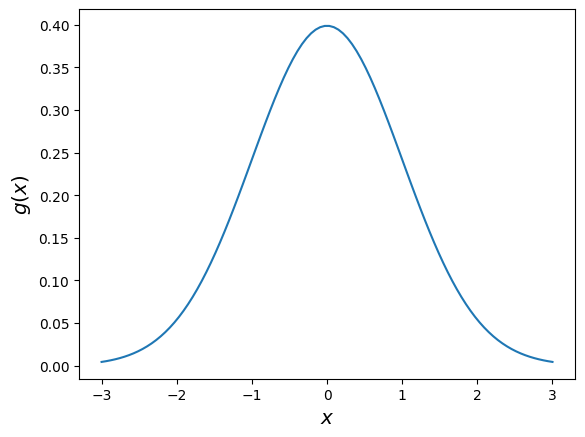

In [9]:
import numpy as np
def gaussian(x, loc, scale):
    return (1.0/(scale*np.sqrt(2*np.pi))) * np.exp(-np.power(x-loc,2)/(2*np.power(scale,2)))  

location = 0
width = 1

xvalues = np.linspace(-3,3,100)
yvalues = gaussian(xvalues, loc=location, scale=width)
# because we pass a numpy array to the gaussian function, it returns an array of the same length
plt.plot(xvalues, yvalues)

plt.xlabel(r"$x$", size="x-large")
plt.ylabel(r"$g(x)$", size="x-large")
plt.show()

### C.2.1.2: Sampling from a Gaussian

The final moving part that we need is the ability to sample (or choose) random numbers that are distributed according to a function of our choosing. We will not go into the details of how this is done and instead we will just use a `numpy` function that does it for us. If you are interested in some ways to do this (there are many ways depending on the complexity of the function that you want to _sample_ from), then you might look up [Inverse Transform Sampling](https://en.wikipedia.org/wiki/Inverse_transform_sampling) or [Rejection Sampling](https://en.wikipedia.org/wiki/Rejection_sampling) as two of the most simple, general methods.

Below we sample a single random number from a gaussian with our chosen parameters and bin and visualise it via a histogram as before. We overlay $g(x)$ from above to see how lucky our sample was.

Where do you expect most draws to fall? If you re-run the cell a few times, is that what you observe?

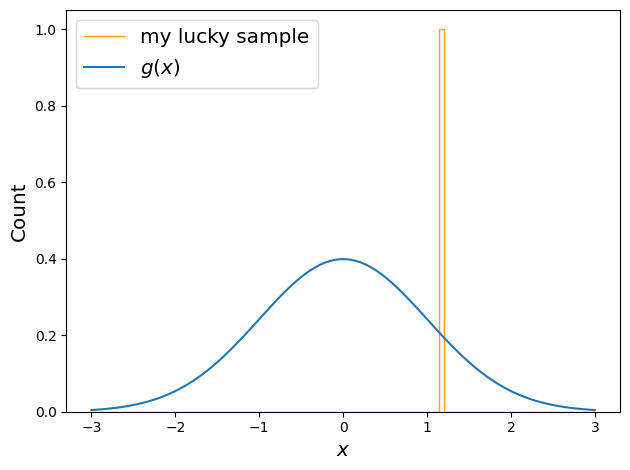

In [10]:
rng = np.random.default_rng()
draw = rng.normal(loc=location, scale=width)

start = -3
stop = 3 # enter maximum binned energy here
nbins = 100 # enter a number of bins here
num = nbins + 1

one_draw_hist = hist1d(data=draw, bins=np.linspace(start=start,stop=stop,num=num))
drawhist1d(hist=one_draw_hist, color="orange", label="my lucky sample")
plt.plot(xvalues, gaussian(xvalues, loc=location, scale=width), label=r"$g(x)$")

plt.xlabel(r"$x$", size="x-large")
plt.ylabel(r"Count", size="x-large")

plt.legend(fontsize="x-large")
plt.tight_layout()
plt.show()

Below we will see what happens if we sample many times from the same distribution and histogram the results. We will use another helper function to draw a Gaussian distribution scaled to the number of samples we have chosen.

How many draws appears to be 'enough' to visually map out $g(x)$? 

_hint:_ Check the documentation for [numpy.Generator.normal](https://numpy.org/doc/stable/reference/random/generated/numpy.random.Generator.normal.html#numpy.random.Generator.normal) to see if there is a simple way to sample more than one number at a time into an array, that we can pass to `hist1d`.

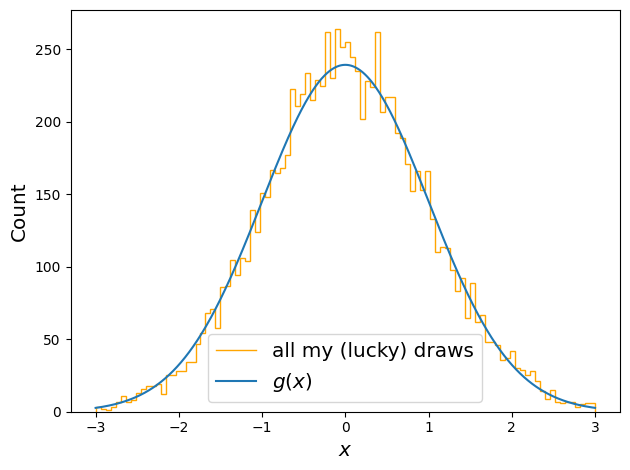

In [11]:
from proj_utils import drawgaus
rng = np.random.default_rng()
num_samples = 10000 # change me
samples = rng.normal(loc=location, scale=width, size=num_samples)

start = -3
stop = 3
nbins = 100
num = nbins + 1

bins = np.linspace(start=start, stop=stop, num=num)
one_draw_hist = hist1d(data=samples, bins=bins)
drawhist1d(hist=one_draw_hist, color="orange", label="all my (lucky) draws")

drawgaus(num_samples, loc=location, scale=width, bins=bins)

plt.xlabel(r"$x$", size="x-large")
plt.ylabel(r"Count", size="x-large")

plt.legend(fontsize="x-large")
plt.tight_layout()
plt.show()

## C.2.2: Finishing the Experiment Simulation

Okay, so we now know how to apply a gaussian smear to a single particle property. If there is no bias in the observation, then we can use the _true_ quantity as the location parameter of the gaussian. The scale of the smear can depend on many things: properties of the particle beign observed, the detector making the measurement, the reconstruction algorithms, etc... 

Can you use the moving parts that have been introduced above to plot the true and smeared proton kinetic energy? Take the proton kinetic energy smearing as 25%

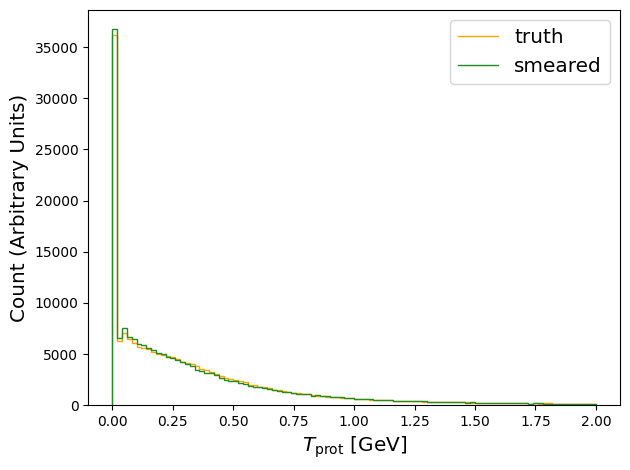

In [12]:
from proj_utils import hist1d, drawhist1d

start = 0
stop = 2
nbins = 100
num = nbins + 1

tprot_hist = hist1d(data=simulated_events_nu_mode["T_proton"], bins=np.linspace(start=start, stop=stop, num=num))
drawhist1d(hist=tprot_hist, color="orange", label="truth")

T_proton_smearing_fraction = 0.25

smeared_tprot = rng.normal(loc=simulated_events_nu_mode["T_proton"], 
                           scale=T_proton_smearing_fraction*simulated_events_nu_mode["T_proton"])

tprot_hist = hist1d(data=smeared_tprot, bins=np.linspace(start=start, stop=stop, num=num))
drawhist1d(hist=tprot_hist, color="forestgreen", label="smeared")


plt.xlabel(r"$T_\mathrm{prot}$ [GeV]", size="x-large")
plt.ylabel("Count (Arbitrary Units)", size="x-large")

plt.legend(fontsize="x-large")
plt.tight_layout()
plt.show()

Because of the shape of the distribution, this probably wont look that dramatic. Try changing the smearing percentage to see the effect that that has.

Another way to validate that you are correctly applying the smearing is to plot the _relative difference_ between your reconstructed quantity and the true quantity, and see if that maps out something approximately gaussian looking with the right width.

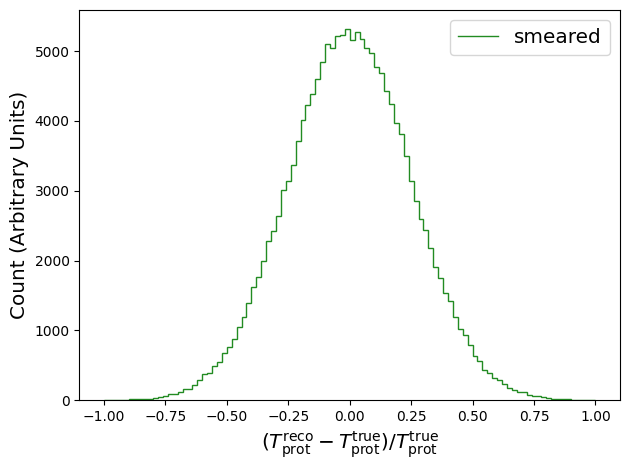

In [13]:
from proj_utils import hist1d, drawhist1d

start = -1
stop = 1
nbins = 100
num = nbins + 1

T_proton_smearing_fraction = 0.25

smeared_tprot = rng.normal(loc=simulated_events_nu_mode["T_proton"], 
                           scale=T_proton_smearing_fraction*simulated_events_nu_mode["T_proton"])
relative_difference = (smeared_tprot-simulated_events_nu_mode["T_proton"])/simulated_events_nu_mode["T_proton"]

tprot_hist = hist1d(data=relative_difference, bins=np.linspace(start=start, stop=stop, num=num))
drawhist1d(hist=tprot_hist, color="forestgreen", label="smeared")

plt.xlabel(r"($T_\mathrm{prot}^\mathrm{reco} - T_\mathrm{prot}^\mathrm{true})/T_\mathrm{prot}^\mathrm{true}$", size="x-large")
plt.ylabel("Count (Arbitrary Units)", size="x-large")

plt.legend(fontsize="x-large")
plt.tight_layout()
plt.show()

### C.2.2.1: Reconstructed Neutrino Energy

As we have learned, no particle detector can directly detect a neutrino, we only see some of the produced particles when a neutrino interacts with matter in a particle detector. We cannot measure the energy of a neutrino reliably by looking at the observable particles produced in neutrino interactions. However, as we have also learned, neutrino oscillation depends on the neutrino energy, so to understand oscillation, we have to do our best to reconstruct the energy of each interacting neutrino. What this often amounts to is adding up all of the visible energy that we see in our detector and accounting for the fact that this is likely to be a biased, smeared estimator for the actual neutrino energy.

We will gloss over the details of how you might extend the above exercise in smearing just the observable proton kinetic energy to a full model for the reconstructed neutrino energy and provide the `ReconstructedNeutrinoEnergy` function for doing so.

The `ReconstructedNeutrinoEnergy` function takes a dictionary of parameter values that can be used to set the smearing widths for each particle type contributor to the reconstructed neutrino energy. In addition to the smearing already discussed, the `"charged_pion_mass_visible_fraction"` parameter can be used to produce a bias in the reconstructed neutrino energy. This parameter controls the fraction of the charged pion mass-energy that is reconstructed in the detector. There are many reasons why it might not be reconstructed, and the details are unimportant.

As this function needs to combine multiple event properties, we pass it the entire event information DataFrame object, rather than referencing specific columns like we have in the past for applying functions to or visualising individual event properties.

Can you make histograms of the true and reconstructed neutrino energies using the `ReconstructedNeutrinoEnergy` below. The usage of the reconstruction function is demonstrated for you.

_hint_: Don't be too put off if the reconstructed distribution has an odd shape, we will work out why in the next section.

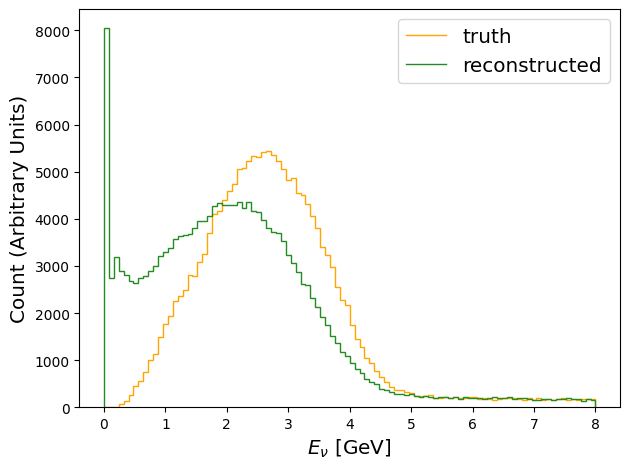

In [14]:
from proj_utils import ReconstructedNeutrinoEnergy

start = 0
stop = 8 # enter maximum binned energy here
nbins = 100 # enter a number of bins here
num = nbins + 1

reconstruction_params = {  "muon_energy_resolution": 0.02, # 2%
                           "electron_energy_resolution": 0.05, #
                           "proton_kinetic_energy_resolution": 0.1, #
                           "charged_pion_kinetic_energy_resolution": 0.1, #
                           "charged_pion_mass_visible_fraction": 0.75, #
                           "neutral_pion_energy_resolution": 0.1 #
                        }

reconstructed_neutrino_energy = ReconstructedNeutrinoEnergy(simulated_events_nu_mode, reconstruction_params)

enu_hist = hist1d(data=simulated_events_nu_mode["E_neutrino"], bins=np.linspace(start=start, stop=stop, num=num))
drawhist1d(hist=enu_hist, color="orange", label="truth")

recoenu_hist = hist1d(data=reconstructed_neutrino_energy, bins=np.linspace(start=start, stop=stop, num=num))
drawhist1d(hist=recoenu_hist, color="forestgreen", label="reconstructed")

plt.xlabel(r"$E_\nu$ [GeV]", size="x-large")
plt.ylabel("Count (Arbitrary Units)", size="x-large")

plt.legend(fontsize="x-large")
plt.tight_layout()
plt.show()

As hinted, this distribution has a weird shape. In the next section we will discus why, and how to understand and 'fix' it. (In reality it doesn't need fixing, it is not incorrect, we just might not be aware of exactly what we are visualising)

# C.3: Making Cuts

## C.3.1: My First Cut

We haven't yet seen the real power of pandas. We will now develop a subsample of the events that we have to use to understand neutrino oscillations. We will give you a contrived example of a _cut_ below to show you the technique, but then it will be up to you to define the cuts to build the relevant event samples for the analysis.

The syntax for making cuts are as follows: 
```python
subsample1 = dataframe[ dataframe["property1"] == some_value ]
subsample2 = dataframe[ dataframe["property2"] < some_value ]
subsample3 = dataframe[ (dataframe["property3"] > some_value) & (dataframe["property3"] < some_value) ]
```

Below we make an example, but analytically useless, cut to demonstrate.

The brackets around the separate cuts are important for pandas to interpret what you want correctly, if you forget them, you may get a warning. After you've run it successfully once, try removing the brackets from the cut code below and seeing what happens.

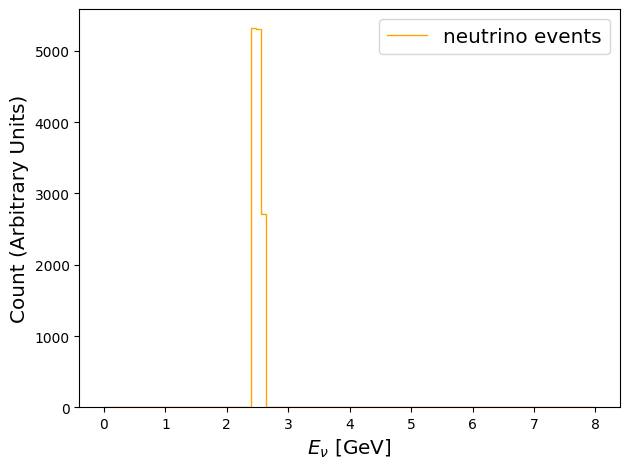

In [15]:
subsample_2_5GeV = simulated_events_nu_mode[ (simulated_events_nu_mode["E_neutrino"] > 2.4) \
                                              & (simulated_events_nu_mode["E_neutrino"] < 2.6) ]
start = 0
stop = 8 # enter maximum binned energy here
nbins = 100 # enter a number of bins here
num = nbins + 1

# then pass the subsample into the histogram helper function
hist = hist1d(data=subsample_2_5GeV["E_neutrino"], bins=np.linspace(start=start, stop=stop, num=num))
drawhist1d(hist=hist, color="orange", label="neutrino events")

plt.xlabel(r"$E_{\nu}$ [GeV]", size="x-large")
plt.ylabel("Count (Arbitrary Units)", size="x-large")

plt.legend(fontsize="x-large")
plt.tight_layout()
plt.show()

## C.3.2: Investigating the Reconstructed Energy

We will now try and resolve what is happening with the reconstructed energy plot above. You should combine what we learned in the last two cells to look at the reconstructed energy distribution for just events with $2.4  < E_\nu < 2.6\ \mathrm{GeV}$.

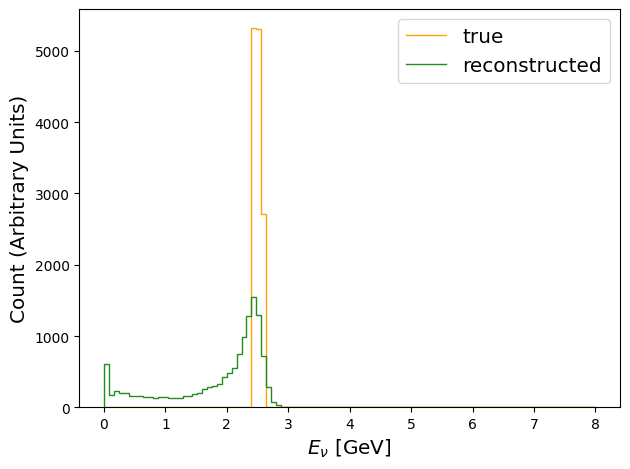

In [16]:
subsample_2_5GeV = simulated_events_nu_mode[ (simulated_events_nu_mode["E_neutrino"] > 2.4) \
                                              & (simulated_events_nu_mode["E_neutrino"] < 2.6) ]
start = 0
stop = 8 # enter maximum binned energy here
nbins = 100 # enter a number of bins here
num = nbins + 1

# then pass the subsample into the histogram helper function
hist = hist1d(data=subsample_2_5GeV["E_neutrino"], bins=np.linspace(start=start, stop=stop, num=num))
drawhist1d(hist=hist, color="orange", label="true")

reconstructed_neutrino_energy = ReconstructedNeutrinoEnergy(subsample_2_5GeV, reconstruction_params)

recoenu_hist = hist1d(data=reconstructed_neutrino_energy, bins=np.linspace(start=start, stop=stop, num=num))
drawhist1d(hist=recoenu_hist, color="forestgreen", label="reconstructed")

plt.xlabel(r"$E_{\nu}$ [GeV]", size="x-large")
plt.ylabel("Count (Arbitrary Units)", size="x-large")

plt.legend(fontsize="x-large")
plt.tight_layout()
plt.show()

You should see a long tail to the left for the reconstructed distribution. We can cut further and thus investigate just the events where the reconstructed energy is much less than the true energy. We can then cut the other way and investigate the events with well reconstructed energy and see if we can spot any patterns that might resolve what is going on.

In [17]:
poor_reco_sample = subsample_2_5GeV[reconstructed_neutrino_energy < 1]
poor_reco_sample

,event_num,pid_neutrino,E_neutrino,is_CC,pid_lepton,E_lepton,T_proton,num_pi0,E_pi0,num_cpi,T_cpi,E_nu_rec_true
277,165276,12,2.4064,0,12,0.0000,0.3217,1,0.3711,0,0.0000,0.6929
357,70842,14,2.4460,0,14,0.0000,0.0000,0,0.0000,0,0.0000,0.0000
361,6184,14,2.5668,1,13,0.6438,0.0000,0,0.0000,0,0.0000,0.6438
366,39397,14,2.5557,0,14,0.0000,0.6399,0,0.0000,0,0.0000,0.6399
403,138726,12,2.5315,0,12,0.0000,0.0000,0,0.0000,0,0.0000,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...
199245,139994,12,2.5283,0,12,0.0000,0.0000,0,0.0000,0,0.0000,0.0000
199349,188544,12,2.4880,0,12,0.0000,0.0958,0,0.0000,0,0.0000,0.0958
199356,86367,14,2.5182,0,14,0.0000,0.3601,0,0.0000,1,0.0157,0.5153
199424,4574,14,2.5062,1,13,0.3409,0.2324,1,0.1926,0,0.0000,0.7659


Compare this to the subset of events with well reconstructed energy. What event property appears to predict badly reconstructed energy?

Why do you think that is?

In [18]:
well_reco_sample = subsample_2_5GeV[reconstructed_neutrino_energy > 2.4]
well_reco_sample

,event_num,pid_neutrino,E_neutrino,is_CC,pid_lepton,E_lepton,T_proton,num_pi0,E_pi0,num_cpi,T_cpi,E_nu_rec_true
14,180549,12,2.4555,1,11,0.4483,0.5401,2,1.4821,0,0.0000,2.4705
74,29465,14,2.5162,1,13,0.6488,1.3325,1,0.2583,1,0.1062,2.4852
136,62927,14,2.5795,1,13,2.0451,0.1378,1,0.1825,0,0.0000,2.3654
137,179061,12,2.5351,1,11,0.3981,0.0000,0,0.0000,1,1.8523,2.3899
219,106836,12,2.5701,1,11,1.6714,0.8936,0,0.0000,0,0.0000,2.5650
...,...,...,...,...,...,...,...,...,...,...,...,...
199610,150932,12,2.5207,1,11,2.4257,0.0935,0,0.0000,0,0.0000,2.5192
199668,125257,12,2.5089,1,11,2.2723,0.2174,0,0.0000,0,0.0000,2.4898
199692,27681,14,2.5111,1,13,2.1324,0.1629,0,0.0000,1,0.0839,2.5187
199821,162635,12,2.5922,1,11,1.7497,0.1930,2,0.6715,0,0.0000,2.6142


Can you make a simple cut that selects a subset of events that tend to have better reconstructed neutrino energy?

Can you remake the truth and reconstructed plot from the end of Section 2 with this cut applied?

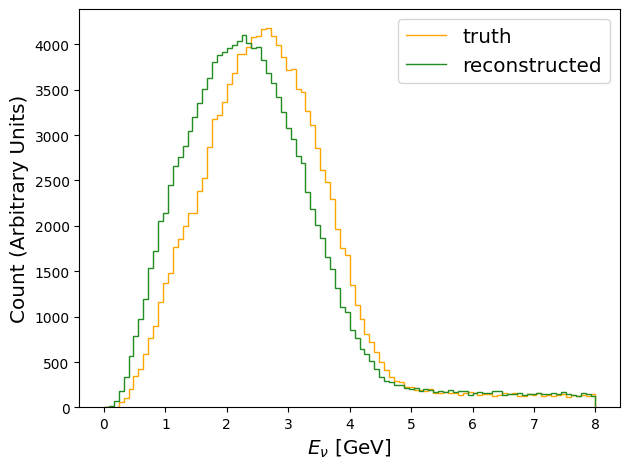

In [19]:
from proj_utils import ReconstructedNeutrinoEnergy

start = 0
stop = 8 # enter maximum binned energy here
nbins = 100 # enter a number of bins here
num = nbins + 1

simulated_events_nu_mode_cc = simulated_events_nu_mode[simulated_events_nu_mode["is_CC"] == 1]

reconstruction_params = {  "muon_energy_resolution": 0.02, # 2%
                           "electron_energy_resolution": 0.05, #
                           "proton_kinetic_energy_resolution": 0.1, #
                           "charged_pion_kinetic_energy_resolution": 0.1, #
                           "charged_pion_mass_visible_fraction": 0.75, #
                           "neutral_pion_energy_resolution": 0.1 #
                        }

reconstructed_neutrino_energy = ReconstructedNeutrinoEnergy(simulated_events_nu_mode_cc, reconstruction_params)

enu_hist = hist1d(data=simulated_events_nu_mode_cc["E_neutrino"], bins=np.linspace(start=start, stop=stop, num=num))
drawhist1d(hist=enu_hist, color="orange", label="truth")

recoenu_hist = hist1d(data=reconstructed_neutrino_energy, bins=np.linspace(start=start, stop=stop, num=num))
drawhist1d(hist=recoenu_hist, color="forestgreen", label="reconstructed")

plt.xlabel(r"$E_\nu$ [GeV]", size="x-large")
plt.ylabel("Count (Arbitrary Units)", size="x-large")

plt.legend(fontsize="x-large")
plt.tight_layout()
plt.show()

Later we might make more cuts to isolate other subsamples that may help us investigate important properties of the data. For now, we are ready to define the event samples that we will use to make our measurement!

# C.4: Oscillation Measurement Event Samples

We now have all the moving parts needed to build histograms of simulated, observed neutrino interactions in our detector. We will then compare these simulations to data to measure the $\delta_\mathrm{CP}$ oscillation parameter that governs the scale of matter-antimatter asymmetry in neutrino oscillations.

Think back to (or go and look again - [here](./OscillationProbabilityPlayground.ipynb)) what you learned about neutrino oscillation theory. By answering a few leading questions, you can hopefully determine what samples we might need to make the measurement:

- What two oscillation channels are relevant for DUNE? In each channel, what is the particle that _always_ leaves the interaction?
- To study matter antimatter asymmetry, we probably need to have samples of both matter and antimatter. So far we've just been looking at matter events, do we have any antimatter events?

Below, see if you can make histograms for each of your oscillation samples.

In [20]:
# Visualise event samples for oscillation measurement here

## C.4.1: Simulating Oscillations

The event samples we have above seem correct, but these events were simulated without oscillations being applied, we need to apply them now to be able to compare to our data, which naturally include oscillations. We can use another helper function to calculate the oscillation weights needed for each sample and they can be included when building the histogram as demonstrated below.

Can you adapt the below code to apply the relevant oscillation weight to all of your event samples?

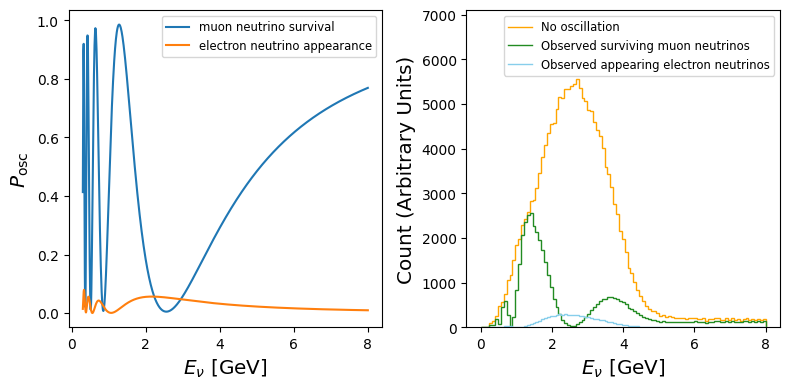

In [21]:
from proj_utils import Probability_Matter_LBL

DUNE_baseline = 1300 # km

osc_params = {
  "experimental_baseline_km": DUNE_baseline,
  "s12sq": 0.31,
  "s13sq": 0.02,
  "s23sq": 0.55,
  "delta": 0.7 * np.pi,
  "Dmsq21": 7.5e-5,
  "Dmsq31": 2.5e-3
}

fig, (axl, axr) = plt.subplots(1,2, figsize=(8, 4))

E = np.linspace(0.3, 8, 1000)
numu_surv_prob, nue_app_prob = \
    Probability_Matter_LBL(E, osc_params, 
                           osc_channels=["numu_survival", "nue_appearance"])

axl.plot(E, numu_surv_prob, label=r"muon neutrino survival")
axl.plot(E, nue_app_prob, label=r"electron neutrino appearance")
axl.set_xlabel(r"$E_{\nu}$ [GeV]", size="x-large")
axl.set_ylabel(r"$P_\mathrm{osc}$", size="x-large")
axl.legend(fontsize="small")
# provide enough space above the histogram for the legend
axr.set_ylim([0,1.2])

enu_hist = hist1d(data=simulated_events_nu_mode["E_neutrino"], bins=np.linspace(start=0, stop=8, num=100))
drawhist1d(hist=enu_hist, color="orange", label="No oscillation")

event_osc_weights_numu_surv, event_osc_weights_nue_app = \
    Probability_Matter_LBL(simulated_events_nu_mode["E_neutrino"],osc_params, osc_channels=["numu_survival", "nue_appearance"])

enu_hist_osc_numu_surv = hist1d(data=simulated_events_nu_mode["E_neutrino"], weights=event_osc_weights_numu_surv ,bins=np.linspace(start=0, stop=8, num=100))
drawhist1d(hist=enu_hist_osc_numu_surv, color="forestgreen", label="Observed surviving muon neutrinos")

enu_hist_osc_nue_app = hist1d(data=simulated_events_nu_mode["E_neutrino"], weights=event_osc_weights_nue_app ,bins=np.linspace(start=0, stop=8, num=100))
drawhist1d(hist=enu_hist_osc_nue_app, color="skyblue", label="Observed appearing electron neutrinos")

axr.set_xlabel(r"$E_{\nu}$ [GeV]", size="x-large")
axr.set_ylabel(r"Count (Arbitrary Units)", size="x-large")
axr.legend(fontsize="small")
# provide enough space above the histogram for the legend
axr.set_ylim([0,7100])

plt.tight_layout()
plt.show()

In [22]:
# Visualise event samples for oscillation measurement here including applying oscillation weights

# C.5: Wrapping Up

We've made a lot of progress. 
- We've taken a truth level simulation of some neutrino events and added a model of detector effects and reconstruction smearing.
- We've learned about making cuts and selecting event samples and then developed the samples we will need to make our measurement.
- We've learned how to apply oscillation weights, completing the experiment simulation and giving up predictions that we can compare directly to data to make our measurement.

If would be useful to wrap all of this up into a single function that takes the event data and parameters of interest and produces histograms of the predicted oscillation. This way when we are making our measurement, we can change the parameters and quickly compare to our data to find the parameter values that best represent out data. A reminder of the parameters that we will need to be able to modify:
- Oscillation parameters, specifically $\mathrm{sin}^{2}(\theta_{23})$, $\Delta\mathrm{m}_{31}^{2}$, $\mathrm{sin}^{2}(\theta_{13})$, and $\delta_\mathrm{CP}$
- Detector smearing and reconstruction parameters

In [23]:
def PredictSamples(simulated_events_nu_mode, simulated_events_antinu_mode, osc_params, reco_params):
    #fill in here

    events_nu_numu_cc = simulated_events_nu_mode[simulated_events_nu_mode["pid_lepton"] == 13]
    events_nu_nue_cc = simulated_events_nu_mode[simulated_events_nu_mode["pid_lepton"] == 11]
    events_nu_antinumu_cc = simulated_events_antinu_mode[simulated_events_antinu_mode["pid_lepton"] == -13]
    events_nu_antinue_cc = simulated_events_antinu_mode[simulated_events_antinu_mode["pid_lepton"] == -11]
    
    reco_E_nu_numu = ReconstructedNeutrinoEnergy(events_nu_numu_cc, reco_params)
    reco_E_nu_nue = ReconstructedNeutrinoEnergy(events_nu_nue_cc, reco_params)
    reco_E_antinu_numu = ReconstructedNeutrinoEnergy(events_nu_antinumu_cc, reco_params)
    reco_E_antinu_nue = ReconstructedNeutrinoEnergy(events_nu_antinue_cc, reco_params)

    event_osc_weights_numu_surv = \
        Probability_Matter_LBL(events_nu_numu_cc["E_neutrino"], osc_params, osc_channels=["numu_survival"])
    event_osc_weights_nue_app = \
        Probability_Matter_LBL(events_nu_nue_cc["E_neutrino"], osc_params, osc_channels=["nue_appearance"])
    
    event_osc_weights_antinumu_surv = \
        Probability_Matter_LBL(events_nu_antinumu_cc["E_neutrino"], osc_params, osc_channels=["antinumu_survival"])
    event_osc_weights_antinue_app = \
        Probability_Matter_LBL(events_nu_antinue_cc["E_neutrino"], osc_params, osc_channels=["antinue_appearance"])

    start = 0
    stop = 8
    nbins = 100
    num = nbins + 1
    
    return hist1d(data=events_nu_numu_cc["E_neutrino"], weights=event_osc_weights_numu_surv, bins=np.linspace(start=start, stop=stop, num=num)), \
           hist1d(data=events_nu_nue_cc["E_neutrino"], weights=event_osc_weights_nue_app, bins=np.linspace(start=start, stop=stop, num=num)), \
           hist1d(data=events_nu_antinumu_cc["E_neutrino"], weights=event_osc_weights_antinumu_surv, bins=np.linspace(start=start, stop=stop, num=num)), \
           hist1d(data=events_nu_antinue_cc["E_neutrino"], weights=event_osc_weights_antinue_app, bins=np.linspace(start=start, stop=stop, num=num)),


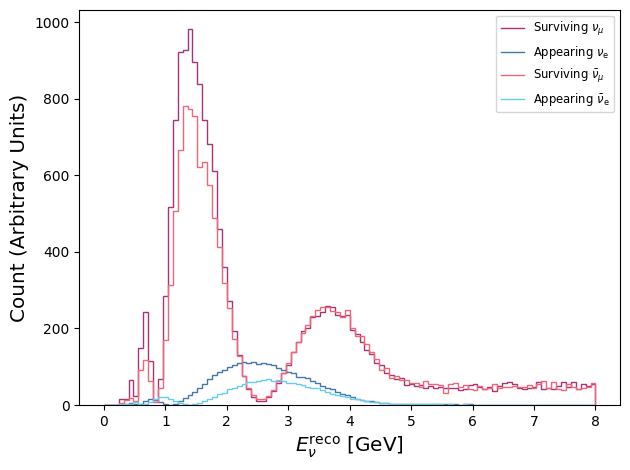

In [24]:
osc_params = {
  "experimental_baseline_km": DUNE_baseline,
  "s12sq": 0.31,
  "s13sq": 0.02,
  "s23sq": 0.55,
  "delta": 0.7 * np.pi,
  "Dmsq21": 7.5e-5,
  "Dmsq31": 2.5e-3
}

reco_params = {  "muon_energy_resolution": 0.02, # 2%
                 "electron_energy_resolution": 0.05, #
                 "proton_kinetic_energy_resolution": 0.1, #
                 "charged_pion_kinetic_energy_resolution": 0.1, #
                 "charged_pion_mass_visible_fraction": 0.75, #
                 "neutral_pion_energy_resolution": 0.1 #
              }

hist_numu_cc, hist_nue_cc, \
  hist_antinumu_cc, hist_antinue_cc = PredictSamples(simulated_events_nu_mode, simulated_events_antinu_mode, \
                                                     osc_params, reco_params)

drawhist1d(hist=hist_numu_cc, color="#AA3377", label=r"Surviving $\nu_\mu$")
drawhist1d(hist=hist_nue_cc, color="#4477AA", label=r"Appearing $\nu_\mathrm{e}$")
drawhist1d(hist=hist_antinumu_cc, color="#EE6677", label=r"Surviving $\bar{\nu}_\mu$")
drawhist1d(hist=hist_antinue_cc, color="#66CCEE", label=r"Appearing $\bar{\nu}_\mathrm{e}$")

plt.xlabel(r"$E_{\nu}^\mathrm{reco}$ [GeV]", size="x-large")
plt.ylabel(r"Count (Arbitrary Units)", size="x-large")
plt.legend(fontsize="small")

plt.tight_layout()
plt.show()